In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 4 seconds. 122 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 20

20

In [25]:
λ_diag = 0.1
λ_skew = 0.01
θ0 = fill(0.0, d)
θ1 = fill(5.0, d)
γ = 1.0
J, θ, min_eigv, max_eigv = random_pars(λ_diag, λ_skew, θ0, θ1, d=d);

In [26]:
min_eigv, max_eigv

(7.224983519237114, 15.80130813751297)

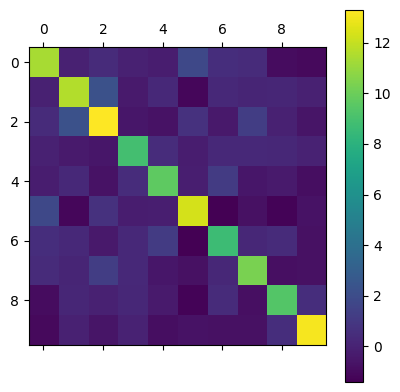

PyObject <matplotlib.colorbar.Colorbar object at 0x71efeff758a0>

In [27]:
matshow(inv(J))
colorbar()

In [28]:
θ |> norm

16.901859845054663

In [29]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

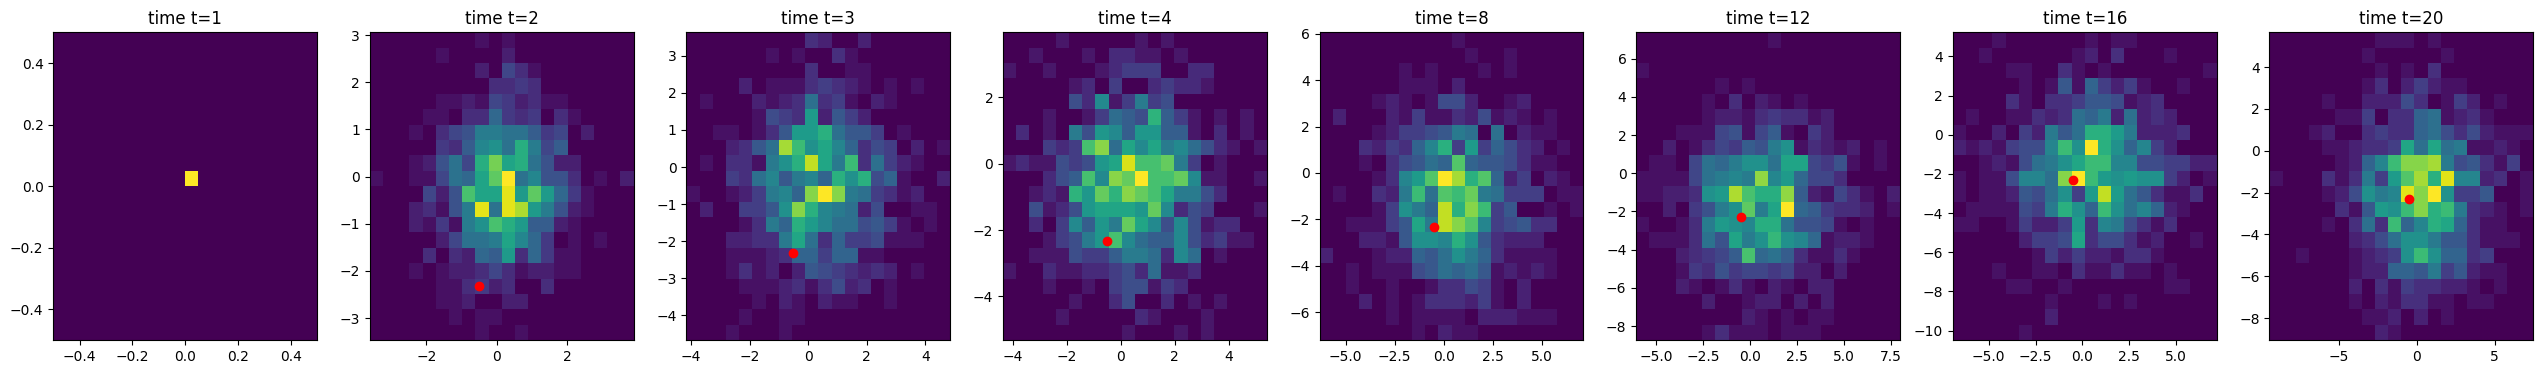

In [30]:
tpoints = [1,2,3,4,8,12,16,20]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

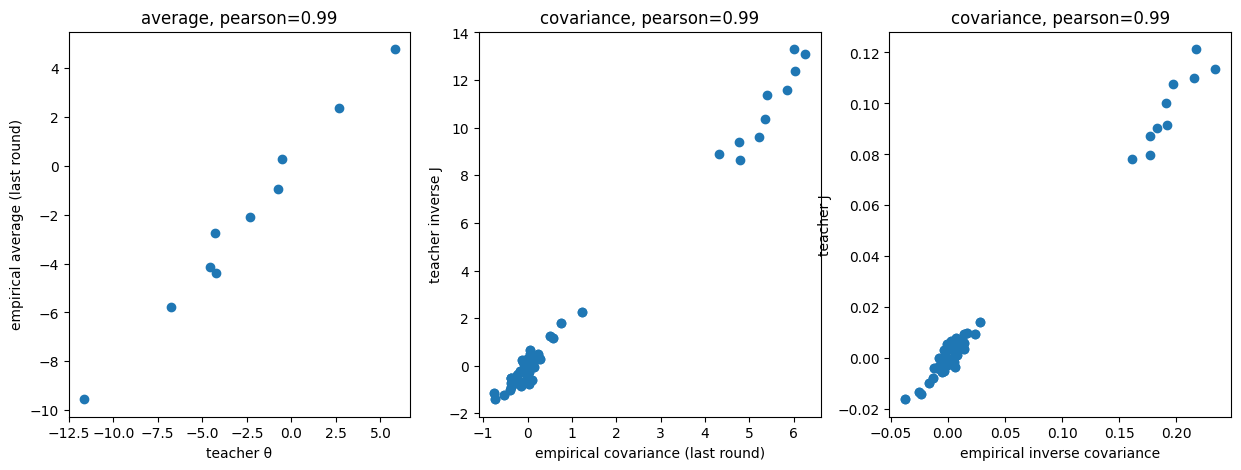

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [31]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [32]:
counts = ones(nsamples, T) ./ nsamples
deltas = fill(1,T)
data = collect_data(x, counts, deltas);

In [36]:
l_values, x_opt, status = learn_nlopt(data, initialize=T, λ=0.0, prior=0.0, ftol_rel=1e-7)

(10.685378530893182, [0.20659766712592204, -0.0017009979808913253, 0.1909661438315965, -0.004250185726282351, -0.03827360685157233, 0.18443830331527145, -0.006685885732058946, -0.0009041417895583735, 0.007317065483902939, 0.2478772606630481  …  0.1351837127684494, -2.161832441777552, -3.0620085910525234, -1.019930310969872, 2.469220618964984, -10.07669542967426, -4.478976200645617, -6.15021768987046, 5.137149155117999, -4.4465444249739265], :FTOL_REACHED)

In [37]:
J_inferred = de.compute_J(x_opt, data.d);

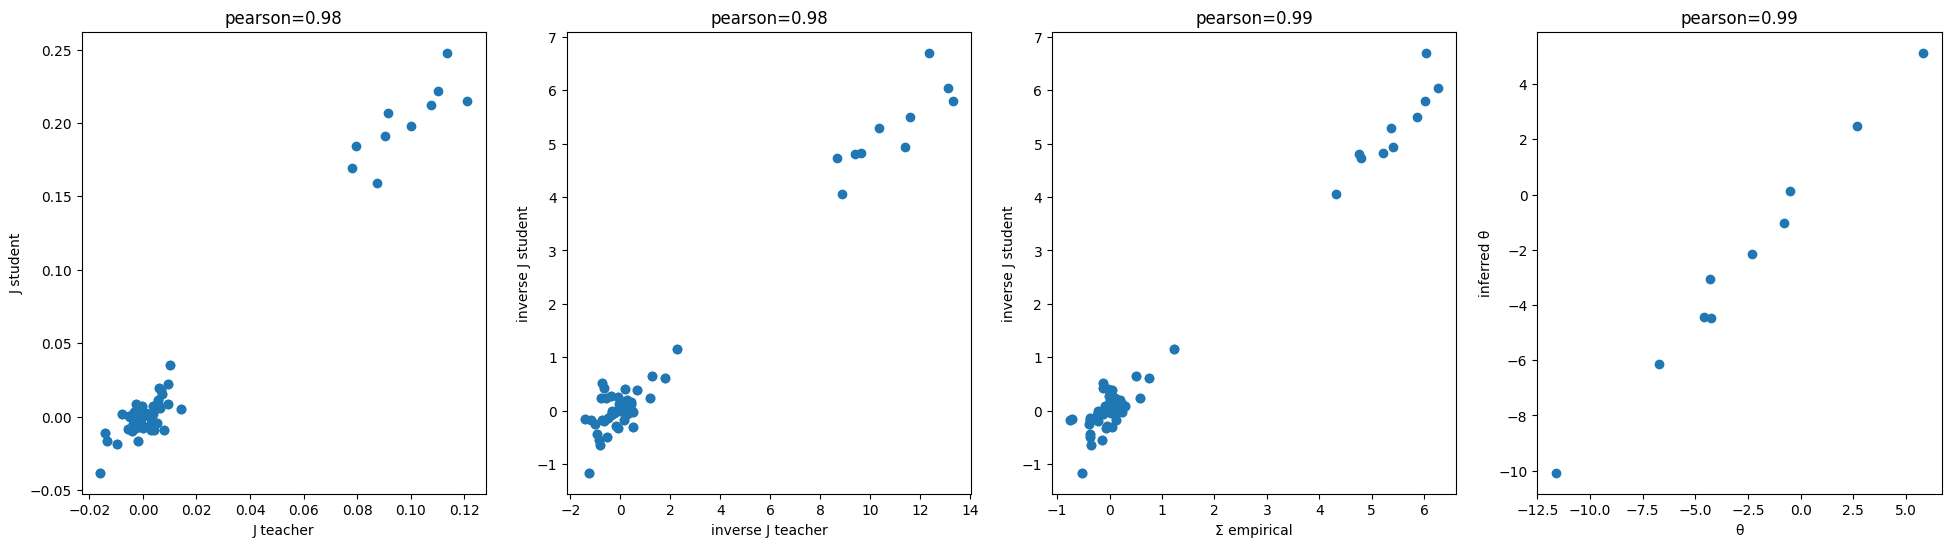

PyObject Text(0.5, 1.0, 'pearson=0.99')

In [38]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
rho_theta = cor(vec(θ), x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")